In [4]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np

initializing coronagraph env. might take a minute.


a:\Projects\DM + RL\.venv\Lib\site-packages\hcipy\mode_basis\zernike.py:138: RuntimeWarning: divide by zero encountered in divide
  res = h1 * zernike_radial(p, q, r, cache) + (h2 + h3 / r2) * zernike_radial(n, q - 2, r, cache)
a:\Projects\DM + RL\.venv\Lib\site-packages\hcipy\mode_basis\zernike.py:138: RuntimeWarning: invalid value encountered in multiply
  res = h1 * zernike_radial(p, q, r, cache) + (h2 + h3 / r2) * zernike_radial(n, q - 2, r, cache)


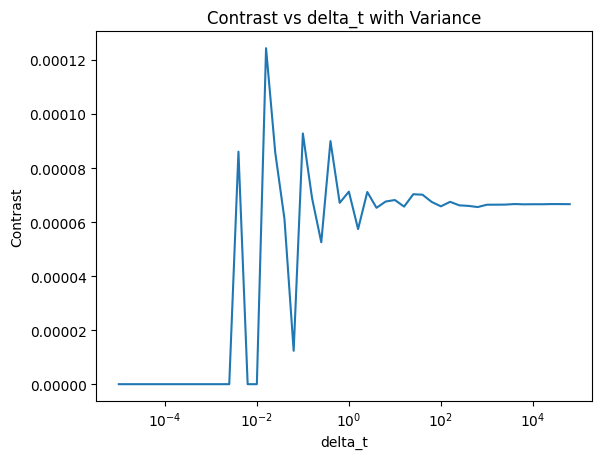

In [ ]:
e = CoronagraphEnvironment(num_modes=100, pixels=50, oversizing_factor=(16 / 15), num_airy=5, coronagraph_charge=6)

delta_ts = [10**(power/5) for power in range(-25, 25)]
contrasts = [[] for _ in delta_ts]
repetitions = 1

for index, dt in enumerate(delta_ts):
    for _ in range(repetitions):
        e.deformable_mirror.flatten
        cont = e.get_contrast(delta_t=dt)
        contrasts[index].append(cont)

means = [np.mean(c) for c in contrasts]
variances = [np.var(c) for c in contrasts]

plt.plot(delta_ts, means)
plt.xscale('log')
plt.xlabel('delta_t')
plt.ylabel('Contrast')
plt.title('Contrast vs delta_t with Variance')
plt.show()



In [29]:
e = CoronagraphEnvironment(num_modes=1, pixels=2500, oversizing_factor=1, num_airy=5, coronagraph_charge=6)


initializing coronagraph env. might take a minute.


AssertionError: get_contrast images different shapes.

In [28]:
resolutions = [res for res in range(2500, 3000, 100)]
contrasts = []
repetitions = 10

for res in resolutions:
    e = CoronagraphEnvironment(num_modes=1, pixels=res, oversizing_factor=1, num_airy=5, coronagraph_charge=6)
    contrasts.append(
            (
                e.get_contrast(delta_t=1e10)
            )
        )

initializing coronagraph env. might take a minute.


KeyboardInterrupt: 

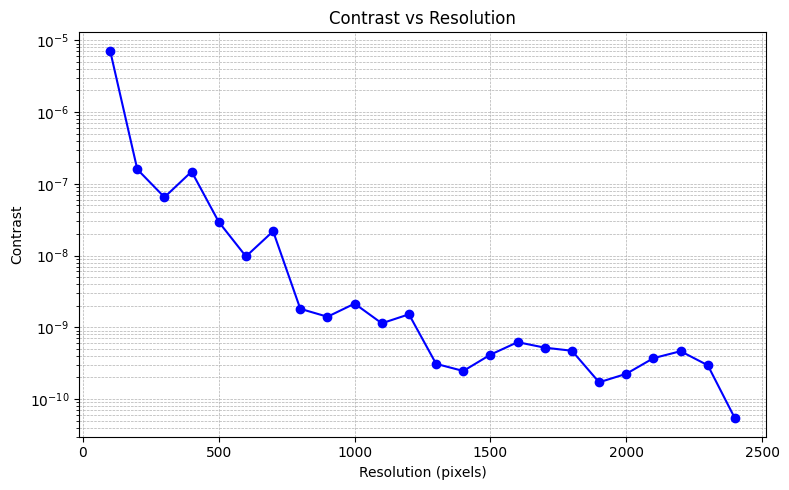

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(resolutions, contrasts, marker='o', linestyle='-', color='b')
plt.xlabel('Resolution (pixels)')
plt.ylabel('Contrast')
plt.title('Contrast vs Resolution')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [36]:
airies = [airy for airy in range(5, 10)]
contrasts = []
repetitions = 10

for airy in airies:
    e = CoronagraphEnvironment(num_modes=1, pixels=500, oversizing_factor=1, num_airy=airy, coronagraph_charge=6)
    contrasts.append(
            (
                e.get_contrast(delta_t=1e10)
            )
        )


initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


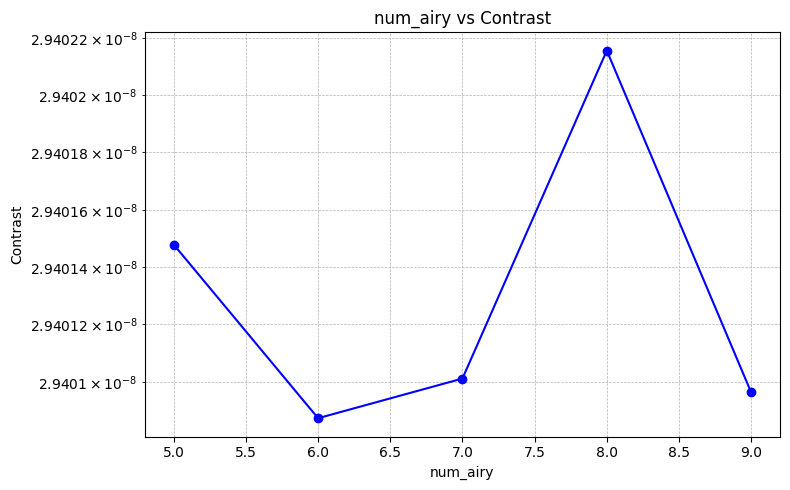

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(airies, contrasts, marker='o', linestyle='-', color='b')
plt.xlabel('Resolution (pixels)')
plt.ylabel('Contrast')
plt.title('Contrast vs Resolution')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('log')
plt.tight_layout()
plt.xlabel('num_airy')
plt.title('num_airy vs Contrast')
plt.show()

In [17]:
oversizing_factors = np.linspace(1, 4, 20)
contrasts = []
repetitions = 10

for factor in oversizing_factors:
    e = CoronagraphEnvironment(num_modes=1, pixels=500, oversizing_factor=factor, num_airy=7, coronagraph_charge=6)
    contrasts.append(e.get_contrast(delta_t=1e15))

initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. m

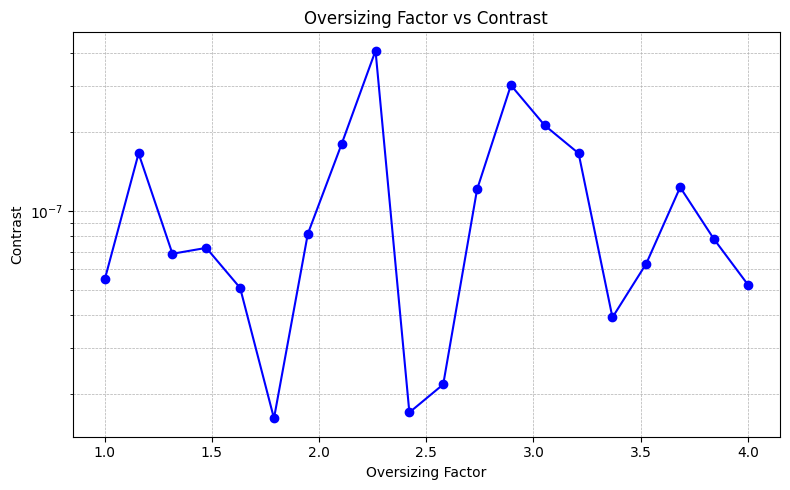

In [19]:
plt.figure(figsize=(8, 5))
plt.ylabel('Contrast')
plt.plot(oversizing_factors, contrasts, marker='o', linestyle='-', color='b')
plt.xlabel('Oversizing Factor')
plt.title('Oversizing Factor vs Contrast')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.yscale('log')
plt.tight_layout()
plt.show()

initializing coronagraph env. might take a minute.
4.951037935865259e-07


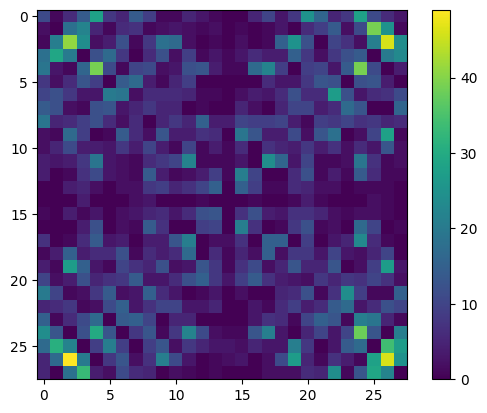

In [9]:
e = CoronagraphEnvironment(num_modes=50, pixels=250, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=2)
plt.imshow(e.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False))
plt.colorbar()
print(e.get_contrast(delta_t=1e10))

initializing coronagraph env. might take a minute.


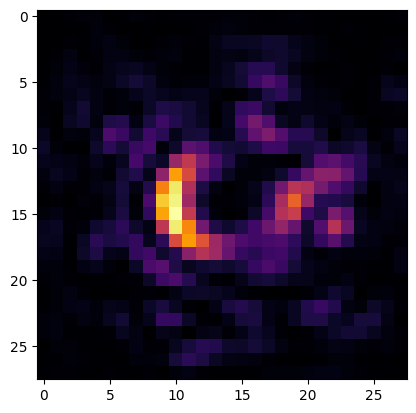

In [25]:
e = CoronagraphEnvironment(num_modes=250, pixels=250, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=2)
e.set_random_dm(noise=0.01)
plt.imshow(e.get_camera_image(delta_t=1e3, coronagraph_enabled=True, crop=False), cmap='inferno')

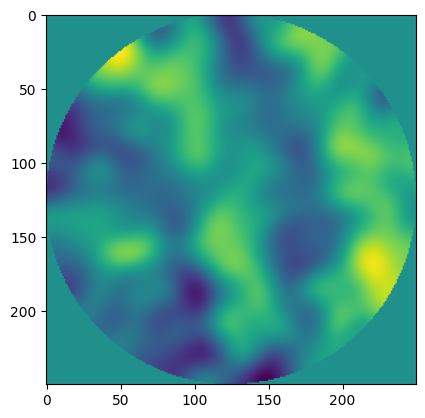

In [38]:
e.set_random_dm(noise=0.01)
plt.imshow(np.reshape(e.deformable_mirror.surface, (250, 250)))

In [2]:
num_modes_options = [5, 10, 25, 50, 100, 200, 300, 500]
noises = np.linspace(1e-7, 1e-2, 50)
all_graphs = []
all_variances = []
repetitions = 100

for num_modes in num_modes_options:
    e = CoronagraphEnvironment(num_modes=num_modes, pixels=20, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=2)
    dm_magnitudes = []
    variances = []
    for noise in noises:
        temp = []
        for _ in range(repetitions):
            e.set_random_dm(noise=noise)
            magnitude = np.linalg.norm(e.deformable_mirror.actuators)
            temp.append(magnitude)
        variances.append(np.var(temp))
        dm_magnitudes.append(np.mean(temp))
    all_variances.append(variances)
    all_graphs.append(dm_magnitudes)


initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.
initializing coronagraph env. might take a minute.


In [55]:
print(all_graphs)

[[np.float64(9.50168802662912e-13), np.float64(2.016460188841297e-09), np.float64(3.936460058578705e-09), np.float64(5.837199742880498e-09), np.float64(7.87727435691887e-09), np.float64(1.0202873149832781e-08), np.float64(1.1724311381251106e-08), np.float64(1.392529271242257e-08), np.float64(1.5931135570599926e-08), np.float64(1.8161521171675867e-08), np.float64(1.9289393565008845e-08), np.float64(2.1591613636368685e-08), np.float64(2.334328950826119e-08), np.float64(2.6058705013603604e-08), np.float64(2.7626883199398946e-08), np.float64(2.9770489262368146e-08), np.float64(3.120997219417409e-08), np.float64(3.378148457126239e-08), np.float64(3.6470618007350936e-08), np.float64(3.76368915671052e-08), np.float64(3.988554813384646e-08), np.float64(4.2298487657069244e-08), np.float64(4.380726776025806e-08), np.float64(4.5562117558996636e-08), np.float64(4.670069612736275e-08), np.float64(4.8731949358627373e-08), np.float64(5.2393395133180587e-08), np.float64(5.459839345383845e-08), np.floa

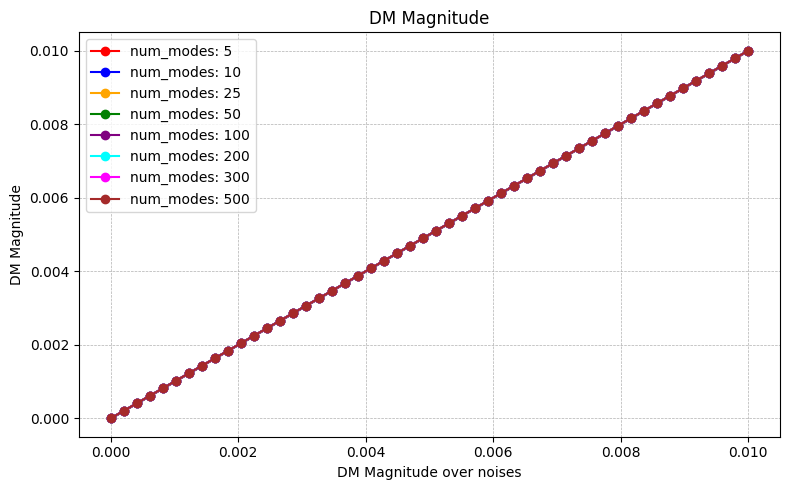

In [3]:
from itertools import cycle



colors = ['r', 'b', 'orange', 'green', 'purple', 'cyan'][:len(num_modes_options)]
# Extend colors list if needed
if len(colors) < len(num_modes_options):
    extra_colors = ['magenta', 'brown', 'olive', 'pink', 'gray', 'teal', 'navy', 'gold', 'lime', 'coral', 'indigo']
    colors = (colors + extra_colors)[:len(num_modes_options)]

plt.figure(figsize=(8, 5))
plt.ylabel('DM Magnitude')
for index, num_modes in enumerate(num_modes_options):
    plt.plot(noises, all_graphs[index], marker='o', linestyle='-', color=colors[index], label=f"num_modes: {num_modes}")
    plt.fill_between(noises, 
                     np.array(all_graphs[index]) - np.sqrt(all_variances[index]), 
                     np.array(all_graphs[index]) + np.sqrt(all_variances[index]), 
                     color=colors[index], alpha=0.2)
    
    
plt.xlabel('DM Magnitude over noises')
plt.title('DM Magnitude')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
e = CoronagraphEnvironment(num_modes=100, pixels=250, oversizing_factor=1, num_airy=7, coronagraph_charge=6, pixels_per_spacial_res=4)

initializing coronagraph env. might take a minute.


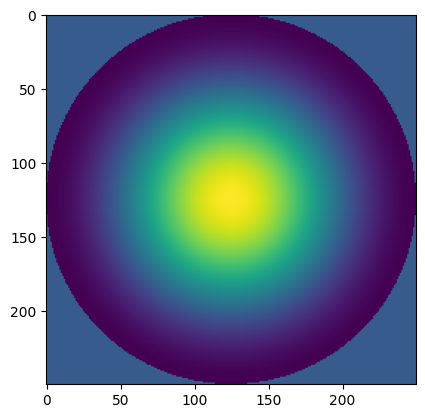

In [45]:
action = [0 for _ in range(100)]
action[0] = 0.1
e.deformable_mirror.flatten()
e.set_dm(action=action)
plt.imshow(np.reshape(e.deformable_mirror.surface, (250, 250)))
